<a href="https://colab.research.google.com/github/scalesynthai/phdai733-group8/blob/main/part1/notebooks/Gropup_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Group 8 — Dataset Selection Analysis
### Group Project Part 1: Real-World AI-Driven Analytics Solution

**Prepared by:** Subba Taniparti
**For:** Harini Mamidala, Christian Gaston Naveen Vishal Bellary
**Course:** PhDAI 733-A02 | **Part 1 due:** Sunday, September 27, 2026

---

## Purpose

This notebook exists so the team picks a dataset on evidence rather than preference. It scores the
five instructor-suggested options against criteria taken directly from the assignment brief, and
ends with a recommendation and a runner-up.

**Please read the recommendation, disagree with it if the reasoning is wrong, and reply with your
pick.** The scoring weights in Section 2 are a judgment call and are the right thing to argue about.

## A note on evidence quality

Two different standards of evidence appear below, and they are labelled throughout:

- **MEASURED** — the dataset was downloaded and profiled by this notebook. Every number is
  reproducible by re-running the cell.
- **DOCUMENTED** — published characteristics from the dataset's source documentation, not verified
  here. Section 6 provides a cell the team can run in Colab to confirm these before we commit.

Only Heart Disease UCI could be retrieved from the environment where this notebook was authored.
That is a restriction of that environment, **not** evidence that the other datasets are hard to
obtain — all five are readily downloadable in Colab.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 1. What the assignment actually requires

The selection criteria are derived from the brief rather than invented, so that the choice is
defensible to the instructor:

| Requirement (from the brief) | What it implies for dataset choice |
|---|---|
| "regression, classification, or clustering" | Must support at least one cleanly; a clear target variable is simpler than inventing one |
| "Dataset Exploration & Preprocessing (**1.5 pages**)" | The largest section. Needs *genuine* cleaning and transformation work to write about |
| "Initial Model Development (1 page)" | Must train and evaluate in the time available |
| "ethical evaluation" / hints ask about "different demographic groups" | Needs attributes that make a subgroup fairness check possible |
| "adequate size and complexity" | Cannot be trivially small or single-dimensional |
| Three people, five days, Google Colab | Must be tractable without cluster compute or heavy engineering |

## 2. Scoring criteria and weights

Weights reflect how the deliverable allocates pages and risk. Preprocessing is weighted highest
because it is the largest written section; feasibility is weighted heavily because the deadline is
five days away and a missed deadline costs more than a suboptimal dataset.


In [ ]:
criteria = pd.DataFrame([
    ('Preprocessing substance', 0.25, 'Does cleaning/encoding give us 1.5 pages of real content?'),
    ('Feasibility in 5 days',   0.25, 'Can 3 people finish it in Colab without infrastructure work?'),
    ('Ethics / subgroup audit', 0.20, 'Are there attributes enabling a real fairness check?'),
    ('Modeling clarity',        0.15, 'Is there a clean target and an obvious task?'),
    ('Size & complexity',       0.15, 'Does it meet "adequate size and complexity"?'),
], columns=['Criterion', 'Weight', 'Question it answers'])

print(f"Weights sum to {criteria['Weight'].sum():.2f}")
criteria

Weights sum to 1.00


,Criterion,Weight,Question it answers
0,Preprocessing substance,0.25,Does cleaning/encoding give us 1.5 pages of re...
1,Feasibility in 5 days,0.25,Can 3 people finish it in Colab without infras...
2,Ethics / subgroup audit,0.20,Are there attributes enabling a real fairness ...
3,Modeling clarity,0.15,Is there a clean target and an obvious task?
4,Size & complexity,0.15,"Does it meet ""adequate size and complexity""?"


## 3. MEASURED — Heart Disease UCI

Downloaded and profiled directly. Every figure below is reproducible.


In [ ]:
URL_HEART = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
heart = pd.read_csv(URL_HEART)

print(f"Shape: {heart.shape[0]} rows x {heart.shape[1]} columns")
print(f"Missing values: {heart.isna().sum().sum()}")
print(f"Duplicate rows: {heart.duplicated().sum()}")
print(f"Target balance: {heart['target'].value_counts().to_dict()} "
      f"({heart['target'].mean():.1%} positive)")
print(f"Positive target rate for classification: {heart['target'].mean():.1%}")
heart.head()


Shape: 303 rows x 14 columns
Missing values: 0
Duplicate rows: 1
Target balance: {1: 165, 0: 138} (54.5% positive)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# The preprocessing trap: categorical variables are stored as integers, so pandas
# reports every column as numeric and get_dummies() silently does nothing.
object_cols = (heart.dtypes == object).sum()
print(f"Columns pandas sees as categorical (object dtype): {object_cols}")
print(f"=> pd.get_dummies(df) would encode {object_cols} columns, i.e. have no effect.\n")

cardinality = pd.DataFrame({
    'unique_values': heart.nunique(),
    'dtype': heart.dtypes.astype(str)})
cardinality['likely_categorical'] = (cardinality['unique_values'] <= 5) & (cardinality.index != 'target')
print("Likely categorical columns:", cardinality[cardinality['likely_categorical']].index.tolist())
cardinality.sort_values('unique_values')


Columns pandas sees as categorical (object dtype): 0
=> pd.get_dummies(df) would encode 0 columns, i.e. have no effect.



,unique_values,dtype,likely_categorical
sex,2,int64,True
fbs,2,int64,True
target,2,int64,False
exang,2,int64,True
restecg,3,int64,True
slope,3,int64,True
thal,4,int64,True
cp,4,int64,True
ca,5,int64,True
oldpeak,40,float64,False


In [ ]:
CATEGORICAL = ['cp', 'restecg', 'slope', 'thal', 'ca']
heart_encoded = pd.get_dummies(
    heart.astype({c: 'category' for c in CATEGORICAL}),
    columns=CATEGORICAL, drop_first=True)

print(f"Correctly encoded: {heart.shape[1]} columns -> {heart_encoded.shape[1]} columns")
print("\nThis single decision is worth a paragraph of Section 2 on its own: a team that")
print("runs get_dummies() without checking dtypes will train on ordinal nonsense, since")
print("chest-pain type 3 is not 'three times' chest-pain type 1.")


Correctly encoded: 14 columns -> 23 columns

This single decision is worth a paragraph of Section 2 on its own: a team that
runs get_dummies() without checking dtypes will train on ordinal nonsense, since
chest-pain type 3 is not 'three times' chest-pain type 1.


In [ ]:
# Subgroup structure for the required ethical evaluation
subgroup = heart.groupby('sex').agg(
    patients=('target', 'size'),
    disease_rate=('target', 'mean')).round(3)
subgroup.index = ['Group 0', 'Group 1']

print(subgroup.to_string())
print(f"Prevalence gap between sex groups: {abs(subgroup['disease_rate'].iloc[0] - subgroup['disease_rate'].iloc[1]):.1%}")
print(f"\nDisease prevalence differs sharply between groups "
      f"({subgroup['disease_rate'].iloc[0]:.1%} vs {subgroup['disease_rate'].iloc[1]:.1%}).")
print("This is what makes a fairness audit meaningful rather than decorative -- but note")
print(f"the smaller group has only {subgroup['patients'].min()} patients, so subgroup")
print("estimates will carry wide uncertainty and should be reported with that caveat.")


         patients  disease_rate
Group 0        96         0.750
Group 1       207         0.449

Disease prevalence differs sharply between groups (75.0% vs 44.9%).
This is what makes a fairness audit meaningful rather than decorative -- but note
the smaller group has only 96 patients, so subgroup
estimates will carry wide uncertainty and should be reported with that caveat.


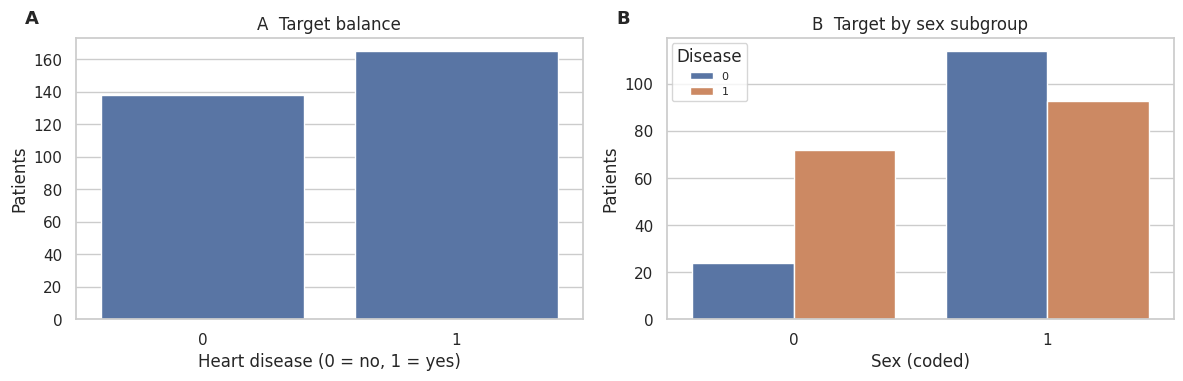

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=heart, x='target', ax=axes[0])
axes[0].set_title('A  Target balance')
axes[0].set_xlabel('Heart disease (0 = no, 1 = yes)')
axes[0].set_ylabel('Patients')

sns.countplot(data=heart, x='sex', hue='target', ax=axes[1])
axes[1].set_title('B  Target by sex subgroup')
axes[1].set_xlabel('Sex (coded)')
axes[1].set_ylabel('Patients')
axes[1].legend(title='Disease', fontsize=8)

for ax, lbl in zip(axes, ['A', 'B']):
    ax.text(-0.10, 1.10, lbl, transform=ax.transAxes, fontsize=13,
            fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('gp_heart_profile.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretation.** Panel A shows the target is close to balanced (54.5% positive), so accuracy
is a usable headline metric and we are not forced into resampling. Panel B shows why the dataset
suits the ethics requirement: disease prevalence differs substantially between the two sex groups,
so a model trained on the pooled data has a real opportunity to perform unevenly across them. The
smaller subgroup contains 96 patients, which is enough to detect a large disparity but not a subtle
one — a limitation we should state rather than hide.

## 4. DOCUMENTED — the other four candidates

These are published characteristics, **not measured here**. Section 6 gives the team a cell to
verify them in Colab before we commit.


In [ ]:
documented = pd.DataFrame([
    dict(Dataset='Heart Disease UCI', Rows='303', Cols=14, Task='Binary classification',
         Target='target (disease)', Demographics='age, sex',
         Known_issues='1 duplicate; categorical vars stored as ints',
         Evidence='MEASURED'),
    dict(Dataset='Diabetes 130-US hospitals', Rows='101,766', Cols=50, Task='Classification (readmission)',
         Target='readmitted (3 classes)', Demographics='race, gender, age bands',
         Known_issues='weight ~97% missing; medical_specialty ~50%; many high-cardinality codes',
         Evidence='DOCUMENTED'),
    dict(Dataset='Online Retail (UCI)', Rows='541,909', Cols=8, Task='Clustering / RFM',
         Target='none (must be engineered)', Demographics='none (country only)',
         Known_issues='~25% missing CustomerID; negative quantities are returns',
         Evidence='DOCUMENTED'),
    dict(Dataset='Credit Card Default', Rows='30,000', Cols=24, Task='Binary classification',
         Target='default.payment.next.month', Demographics='SEX, EDUCATION, MARRIAGE, AGE',
         Known_issues='undocumented category codes in EDUCATION/MARRIAGE; imbalanced ~22%',
         Evidence='DOCUMENTED'),
    dict(Dataset='NYC Taxi', Rows='millions/month', Cols=19, Task='Regression (fare/duration)',
         Target='fare_amount or trip_duration', Demographics='none',
         Known_issues='parquet files; GPS/fare outliers; size strains Colab RAM',
         Evidence='DOCUMENTED'),
])
documented


,Dataset,Rows,Cols,Task,Target,Demographics,Known_issues,Evidence
0,Heart Disease UCI,303,14,Binary classification,target (disease),"age, sex",1 duplicate; categorical vars stored as ints,MEASURED
1,Diabetes 130-US hospitals,"101,766",50,Classification (readmission),readmitted (3 classes),"race, gender, age bands",weight ~97% missing; medical_specialty ~50%; m...,DOCUMENTED
2,Online Retail (UCI),"541,909",8,Clustering / RFM,none (must be engineered),none (country only),~25% missing CustomerID; negative quantities a...,DOCUMENTED
3,Credit Card Default,"30,000",24,Binary classification,default.payment.next.month,"SEX, EDUCATION, MARRIAGE, AGE",undocumented category codes in EDUCATION/MARRI...,DOCUMENTED
4,NYC Taxi,millions/month,19,Regression (fare/duration),fare_amount or trip_duration,none,parquet files; GPS/fare outliers; size strains...,DOCUMENTED


## 5. Scoring

Scores are 1–5 on each criterion. They encode judgment, not fact — **this table is the thing to
argue with.**

Reasoning behind the two decisive columns:

- **Feasibility** penalises NYC Taxi (parquet files of millions of rows will strain Colab's free
  RAM and cost us days on engineering rather than analysis) and Diabetes 130 (50 columns of
  high-cardinality medical codes is a large encoding job for a 1.5-page section).
- **Ethics** penalises Online Retail and NYC Taxi heavily, because neither carries demographic
  attributes. The assignment requires ethical evaluation and the hints explicitly ask how the model
  performs "across different demographic groups". With those datasets that section becomes abstract
  commentary, which is exactly the kind of writing this instructor marks down.


In [ ]:
scores = pd.DataFrame([
    #                              prep  feas  ethics  model  size
    ('Heart Disease UCI',            4,    5,     5,     5,     3),
    ('Diabetes 130-US hospitals',    5,    2,     5,     3,     5),
    ('Online Retail (UCI)',          5,    3,     1,     2,     5),
    ('Credit Card Default',          4,    4,     5,     5,     4),
    ('NYC Taxi',                     3,    1,     1,     4,     5),
], columns=['Dataset', 'Preprocessing substance', 'Feasibility in 5 days',
            'Ethics / subgroup audit', 'Modeling clarity', 'Size & complexity']
).set_index('Dataset')

weights = criteria.set_index('Criterion')['Weight']
scores['WEIGHTED TOTAL'] = (scores * weights).sum(axis=1).round(2)
print("Top-ranked dataset by weighted score:", scores['WEIGHTED TOTAL'].idxmax(), scores['WEIGHTED TOTAL'].max())
scores.sort_values('WEIGHTED TOTAL', ascending=False)


,Preprocessing substance,Feasibility in 5 days,Ethics / subgroup audit,Modeling clarity,Size & complexity,WEIGHTED TOTAL
Dataset,,,,,,
Heart Disease UCI,4,5,5,5,3,4.45
Credit Card Default,4,4,5,5,4,4.35
Diabetes 130-US hospitals,5,2,5,3,5,3.95
Online Retail (UCI),5,3,1,2,5,3.25
NYC Taxi,3,1,1,4,5,2.55


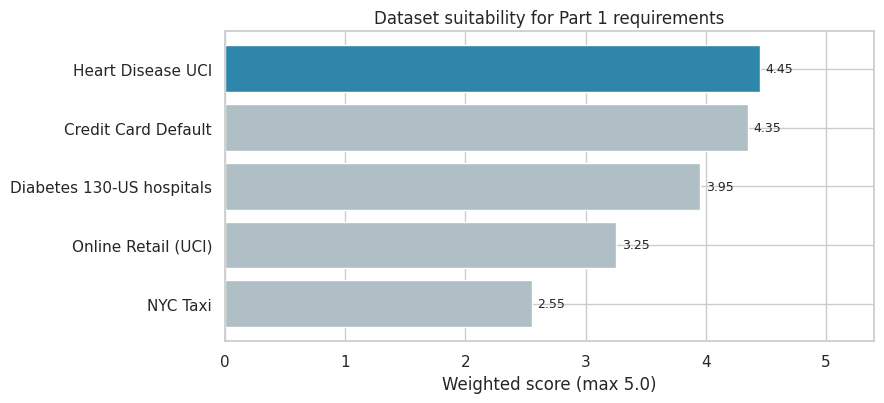

In [ ]:
ranked = scores.sort_values('WEIGHTED TOTAL')

fig, ax = plt.subplots(figsize=(9, 4.2))
colors = ['#2E86AB' if v == ranked['WEIGHTED TOTAL'].max() else '#B0BEC5'
          for v in ranked['WEIGHTED TOTAL']]
ax.barh(ranked.index, ranked['WEIGHTED TOTAL'], color=colors)
for i, v in enumerate(ranked['WEIGHTED TOTAL']):
    ax.text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('Weighted score (max 5.0)')
ax.set_title('Dataset suitability for Part 1 requirements')
ax.set_xlim(0, 5.4)
plt.tight_layout()
plt.savefig('gp_scores.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Verify before committing

Run this in Colab to confirm the DOCUMENTED rows above. If Credit Card Default loads easily for
you, it is a legitimate alternative — see the recommendation.


In [ ]:
# Uncomment and run in Colab. Kaggle sources need `kaggle datasets download` or a manual upload.
CANDIDATES = {
    'Heart Disease UCI': URL_HEART,
    # 'Credit Card Default': '<paste a working URL or upload the CSV>',
    # 'Online Retail':       '<paste a working URL or upload the CSV>',
}

for name, url in CANDIDATES.items():
    try:
        probe = pd.read_csv(url, nrows=2000)
        print(f"OK   {name}: loaded, {probe.shape[1]} columns, "
              f"{probe.isna().sum().sum()} nulls in first 2000 rows")
    except Exception as e:
        print(f"FAIL {name}: {type(e).__name__} -- {str(e)[:80]}")


OK   Heart Disease UCI: loaded, 14 columns, 0 nulls in first 2000 rows


## 7. Recommendation

### Primary: **Heart Disease UCI** (weighted 4.45)

It wins on the two heaviest criteria simultaneously. Feasibility is the practical argument — 303
rows means every cell runs instantly, so all five days go into analysis and writing rather than
waiting on compute or debugging memory errors. Ethics is the substantive argument — the sex
attribute lets our required ethical section report a measured subgroup comparison instead of
speculation, and the 75% versus 45% prevalence gap means there is something real to find.

Its one genuine weakness is size: 303 rows is modest against "adequate size and complexity." Two
things offset this. The complexity is in the *feature structure* rather than the row count — 13
predictors mixing continuous measurements with five categorical codes needing correct encoding.
And the small sample is itself an honest analytical point: it justifies cross-validation over a
single split and warrants explicit caveats on subgroup estimates, which is the kind of reasoning
this instructor has rewarded.

### Runner-up: **Credit Card Default** (weighted 4.35)

Close enough that it is a reasonable choice. It is larger (30,000 rows), carries four demographic
attributes for the ethics section, and has a documented quirk worth writing about — undocumented
category codes in EDUCATION and MARRIAGE. It ranks second only because we have not yet confirmed a
reliable download path and its class imbalance (~22% default) adds a complication we would need to
handle in Section 3.

**If anyone can confirm a working download for Credit Card Default, it becomes a genuinely
competitive option and we should discuss it.**

### Not recommended

- **NYC Taxi** (2.55): no demographic attributes, so the required ethics section becomes abstract;
  and the file sizes risk spending our five days on data engineering.
- **Online Retail** (3.25): no target variable and no demographics. It would force us into
  clustering *and* leave the ethics section thin.
- **Diabetes 130** (3.95): excellent dataset, wrong deadline. Fifty columns including
  high-cardinality medical codes is a serious encoding effort for five days.

### What would change this recommendation

- If either of you has prior experience with one of these, that outweighs a 0.15 scoring gap.
- If the team would rather do clustering than classification, Online Retail becomes the choice and
  we would need to ask the instructor how to handle the ethics section without demographics.
- If you think I have weighted feasibility too heavily, say so — that single weight is doing most
  of the work in this ranking.

## Next steps

1. **Reply with your pick** (agree, or name a different one) — ideally today so we keep the timeline.
2. Once decided, I will set up the GitHub repo and a shared Colab notebook with data loading done,
   so nobody duplicates setup.
3. We then split the four report sections. My suggestion: Christian takes Sections 1 and 4, Harini
   takes Section 2 (the largest), and I take Section 3 plus the repo — but that is open.
## Sections
1. Introduction & Problem Framing (0.5 pages)
2. Dataset Exploration & Preprocessing (1.5 pages)
3. Initial Model Development (1 page)
4. Team Collaboration Process (0.5 page)
